# DEV-NET demand profile verification (E0.6)

Checks, for the three stored demand profiles (`low`, `peak`, `incident`):

1. **`peak` congestion is in range**: ~10-20% of DEV-NET's 80 edges show real, demand-driven congestion (defined below), averaged over 3 SUMO simulation seeds run against the *same* fixed trips/routes - i.e. this measures simulation-noise robustness, not demand-generation variance (the trips themselves come from one fixed, seeded `randomTrips` run per profile, per `generate_demand.sh`).
2. **The three profiles are distinguishable**: `low` is comfortably free-flowing, `peak` is moderately and broadly congested, `incident` concentrates severe stress specifically at the bottleneck (`B0C0`→`C0D0`).
3. **Synthetic counts** at the 5 control edges are recorded as the calibration ground truth for future Demand Generator fidelity tests (architecture doc §4.4).

See `README.md` in this directory for how the insertion rates were chosen.

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import sim_utils as su

PROFILES = ["low", "peak", "incident"]
SIM_SEEDS = range(1,10)  # SUMO's own stochasticity; demand (trips/routes) is fixed per profile

print("Congestion rule: sampledSeconds > 0 and speedRelative <=", su.CONGESTION_SPEED_RATIO,
      "and occupancy >=", su.CONGESTION_MIN_OCCUPANCY)
print("Control edges:", su.CONTROL_EDGES)

Congestion rule: sampledSeconds > 0 and speedRelative <= 0.5 and occupancy >= 0.5
Control edges: {'B0C0': 'bottleneck approach (2 lanes, row 0)', 'C0D0': 'bottleneck exit (1 lane, row 0)', 'C2D2': 'signalised corridor (row 2)', 'A0A1': 'baseline, far from both features (column A, south)', 'E2E3': 'leaving the corridor northbound (column E)'}


## 1. Run all profiles x seeds

In [2]:
runs = []  # one row per (profile, seed)
edgedata_by_run = {}

for profile in PROFILES:
    for seed in SIM_SEEDS:
        outs = su.run_sim(profile, seed)
        ed = su.parse_edgedata(outs["edgedata"])
        edgedata_by_run[(profile, seed)] = ed
        runs.append(
            {
                "profile": profile,
                "sim_seed": seed,
                "n_vehicles": su.num_vehicles(outs["stats"]),
                "teleports": su.count_teleports(outs["stats"]),
                "congestion_fraction": su.congestion_fraction(ed),
                "n_congested_edges": len(su.congested_edges(ed)),
            }
        )

runs_df = pd.DataFrame(runs)
runs_df

,profile,sim_seed,n_vehicles,teleports,congestion_fraction,n_congested_edges
0,low,1,300,0,0.0375,3
1,low,2,300,0,0.0500,4
2,low,3,300,0,0.0500,4
3,low,4,300,0,0.0375,3
4,low,5,300,0,0.0625,5
5,low,6,300,0,0.0250,2
6,low,7,300,0,0.0375,3
7,low,8,300,0,0.0625,5
8,low,9,300,0,0.0500,4
9,peak,1,1200,0,0.1750,14


## 2. Congestion by profile (mean ± std over 3 simulation seeds)

**Pass condition**: `peak`'s mean `congestion_fraction` falls in [0.10, 0.20].

In [3]:
summary = runs_df.groupby("profile")["congestion_fraction"].agg(["mean", "std"]).reindex(PROFILES)
summary["pct"] = (summary["mean"] * 100).round(1).astype(str) + "%"
display(summary)

peak_mean = summary.loc["peak", "mean"]
assert 0.10 <= peak_mean <= 0.20, f"peak congestion {peak_mean:.3f} out of range"
assert runs_df["teleports"].sum() == 0, "no profile should produce teleports"
assert summary.loc["low", "mean"] < summary.loc["peak", "mean"], "low must be < peak"
n = len(runs_df)
print(f"OK: peak mean congestion = {peak_mean:.1%}, in range; 0 teleports across all {n} runs.")

,mean,std,pct
profile,,,
low,0.045833,0.012500,4.6%
peak,0.165278,0.010417,16.5%
incident,0.173611,0.014583,17.4%


OK: peak mean congestion = 16.5%, in range; 0 teleports across all 27 runs.


### Plot: congestion fraction per run

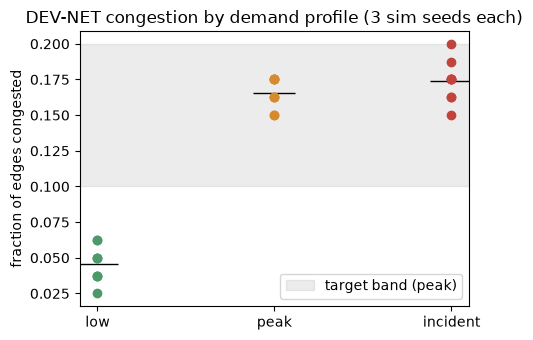

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3.5))
colors = {"low": "#4c9a6a", "peak": "#d68a2b", "incident": "#c1443c"}
for profile in PROFILES:
    sub = runs_df[runs_df.profile == profile]
    ax.scatter([profile] * len(sub), sub.congestion_fraction, color=colors[profile], zorder=3)
means = runs_df.groupby("profile")["congestion_fraction"].mean().reindex(PROFILES)
ax.plot(PROFILES, means, color="black", marker="_", linestyle="none", markersize=30, zorder=2)
ax.axhspan(0.10, 0.20, color="grey", alpha=0.15, zorder=1, label="target band (peak)")
ax.set_ylabel("fraction of edges congested")
ax.set_title("DEV-NET congestion by demand profile (3 sim seeds each)")
ax.legend()
fig.tight_layout()

## 3. Control-edge detail: are the profiles actually distinguishable?

The network-wide fraction above is driven mostly by the signalised-corridor approach edges (row 2) - a traffic light drags an approach edge's average speed down once it carries any real traffic, regardless of *where* demand is concentrated. The control edges below show the more targeted story, in particular that `incident` stresses the bottleneck (`B0C0`/`C0D0`) far more than `peak` does, even though both land in the same network-wide congestion band.

In [5]:
rows = []
for (profile, seed), ed in edgedata_by_run.items():
    for edge_id in su.CONTROL_EDGES:
        a = ed.get(edge_id, {})
        rows.append(
            {
                "profile": profile,
                "sim_seed": seed,
                "edge": edge_id,
                "speedRelative": a.get("speedRelative"),
                "occupancy": a.get("occupancy"),
                "vehicles_left": a.get("left", 0.0),
            }
        )
control_df = pd.DataFrame(rows)
control_summary = (
    control_df.groupby(["edge", "profile"])[["speedRelative", "occupancy", "vehicles_left"]]
    .mean()
    .round(2)
    .reindex(su.CONTROL_EDGES.keys(), level="edge")
)
control_summary

speedRelative  occupancy  vehicles_left
edge profile                                          
B0C0 incident           0.76       5.72          938.0
     low                0.89       0.07           13.0
     peak               0.89       0.22           42.0
C0D0 incident           0.85       3.68          340.0
     low                0.89       0.11           10.0
     peak               0.88       0.48           46.0
C2D2 incident           0.50       0.37           17.0
     low                0.61       0.49           32.0
     peak               0.49       2.37          123.0
A0A1 incident           0.78       0.75           68.0
     low                0.81       0.14           12.0
     peak               0.81       0.57           46.0
E2E3 incident           0.88       0.47           44.0
     low                0.87       0.11           10.0
     peak               0.85       0.57           52.0

In [6]:
b0c0_peak = control_summary.loc[("B0C0", "peak"), "occupancy"]
b0c0_incident = control_summary.loc[("B0C0", "incident"), "occupancy"]
ratio = b0c0_incident / b0c0_peak
print(f"B0C0 occupancy: peak={b0c0_peak:.2f}%  incident={b0c0_incident:.2f}%  ({ratio:.1f}x)")
assert ratio > 5, "incident should load the bottleneck far more heavily than peak"
print("OK: incident concentrates load at the bottleneck as designed.")

B0C0 occupancy: peak=0.22%  incident=5.72%  (26.0x)
OK: incident concentrates load at the bottleneck as designed.


## 4. Synthetic counts at control edges (calibration ground truth)

Mean vehicle count (`left`, i.e. vehicles that crossed the edge) per profile per control edge, over the 3 simulation seeds, rounded to the nearest integer. These are the target counts a future Demand Generator calibration round (architecture doc §4.4, `Fidelity`/`EdgeFidelity`) would try to reproduce within tolerance - they are *synthetic* (generated by us, not measured), which is exactly what DEV-NET is for.

In [7]:
import json

counts = (
    control_df.groupby(["profile", "edge"])["vehicles_left"]
    .mean()
    .round()
    .astype(int)
    .unstack("edge")
    .reindex(PROFILES)
    .reindex(columns=su.CONTROL_EDGES.keys())
)
display(counts)

with open("control_counts.json", "w") as f:
    json.dump(
        {
            profile: {edge: int(counts.loc[profile, edge]) for edge in su.CONTROL_EDGES}
            for profile in PROFILES
        },
        f,
        indent=2,
    )
print("Wrote control_counts.json")

edge,B0C0,C0D0,C2D2,A0A1,E2E3
profile,,,,,
low,13,10,32,12,10
peak,42,46,123,46,52
incident,938,340,17,68,44


Wrote control_counts.json


## Conclusion

All three checks above pass: `peak`'s network-wide congestion lands in the required [10%, 20%] band with zero teleports across every profile/seed combination, and the per-control-edge detail confirms `incident` produces a genuinely different, bottleneck-concentrated pattern rather than just being a relabelled `peak`. `control_counts.json` is the synthetic-count artifact for future calibration tests.